# Publication Figures

In [27]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
import numpy as np
import os
import re
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from matplotlib.collections import PathCollection
from plot_helpers import *
from scipy.special import gamma

# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler
from matplotlib.lines import Line2D

plt.style.use("presentation.mplstyle")
clist = ['#85A5CD', '#496391', '#92C36D', '#EE9432', '#5C3C8B', '#7D62A2', '#FDF3CC']
cdict = {
    "lightblue": '#85A5CD',
    "darkblue": '#496391',
    "green": '#92C36D',
    "lightgreen": '#BDDAA7',
    "orange": '#EE9432',
    "purple": '#5C3C8B',
    "purple2": '#7D62A2',
    "lightpurple": '#C0ABDC',
    "yellow": "#FDEBCC",
    "red":'#C00000',
    "black": '#000000'
}
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

mpl.rcParams['axes.prop_cycle'] = cycler(color=clist)
plotsize = 5

In [28]:
PLOT_CONFIG = {
    'plotsize': 5,
    'timewindow': 25,
    'rolling_window': 30,
}

def create_inset_legend(axes_list, ncol=2, fontsize=14, markerscale=2):
    """
    Move legend below the axis using inset positioning.
    This prevents legend from obscuring data while keeping it closely associated with the plot.
    """
    for ax in axes_list:
        leg_ax = inset_axes(
            ax,
            width="100%",
            height="20%",
            loc="lower center",
            bbox_to_anchor=(0, -0.5, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        leg_ax.axis("off")
        handles, labels = ax.get_legend_handles_labels()
        leg_ax.legend(
            handles,
            labels,
            loc="center",
            ncol=ncol,
            frameon=True,
            fontsize=fontsize,
            markerscale=markerscale
        )

def add_subplot_labels(axes_list, labels_list):
    """Add panel labels (a), b), c), etc.) to subplots for figure referencing."""
    for ax, label in zip(axes_list, labels_list):
        ax.text(-0.25, 1.08, label, transform=ax.transAxes, va='top', ha='left')

def align_subplot_limits(axes_array, axis='y'):
    """
    Normalize axis limits across adjacent subplots.
    Ensures fair visual comparison by using identical scales within each column.
    """
    for r in range(axes_array.shape[1]):
        row_axes = axes_array[:, r]
        
        if axis == 'y':
            get_lim, set_lim = lambda ax: ax.get_ylim(), lambda ax, lim: ax.set_ylim(lim)
        else:
            get_lim, set_lim = lambda ax: ax.get_xlim(), lambda ax, lim: ax.set_xlim(lim)
        
        lims = [get_lim(ax) for ax in row_axes]
        min_val = min(lim[0] for lim in lims)
        max_val = max(lim[1] for lim in lims)
        
        for ax in row_axes:
            set_lim(ax, (min_val, max_val))

def downsample_plot_data(x, y, max_points=50000, window=1):
    """
    Reduce data density without losing trends.
    Applies optional rolling average before downsampling to preserve smoothness.
    """
    if isinstance(x, pd.Series):
        x = x.values
    if isinstance(y, pd.Series):
        y = y.to_numpy()
    
    if window > 1:
        y = pd.Series(y).rolling(window=window).mean().values
    
    step = max(1, len(x) // max_points)
    return x[::step], y[::step]

## Figure 2: Model Comparison at DPn = 400

In [29]:
dpn = 400

kmc_data = read_data(f"../kmc_src/spedup_cpp_files/T_260/long_time/run_{dpn}")
kmc_df = process_data(kmc_data)

mom_data = read_data_mom(f"../mom_src/T260/run{dpn}")
mom_df = process_data_mom(mom_data)

In [30]:
# Calculate parameters from moments
mom_df['variance'] = mom_df['Rep_1l_pp2'] - mom_df['Rep_1l_pp1']**2
mom_df['alpha'] = mom_df['Rep_1l_pp1']**2 / mom_df['variance']  # shape parameter
mom_df['beta'] = mom_df['Rep_1l_pp1'] / mom_df['variance']      # rate parameter

# Calculate f(1) = (beta^alpha / Gamma(alpha)) * exp(-beta)
mom_df['f_of_1'] = (mom_df['beta']**mom_df['alpha'] / gamma(mom_df['alpha'])) * np.exp(-mom_df['beta'])

mom_df['netrate_BS_corrected'] = mom_df['netrate_BS'] * (1-mom_df['f_of_1'])
mom_df['Rp/Rt_corr_f1'] = mom_df['netrate_BS_corrected'] / mom_df['netrate_R']

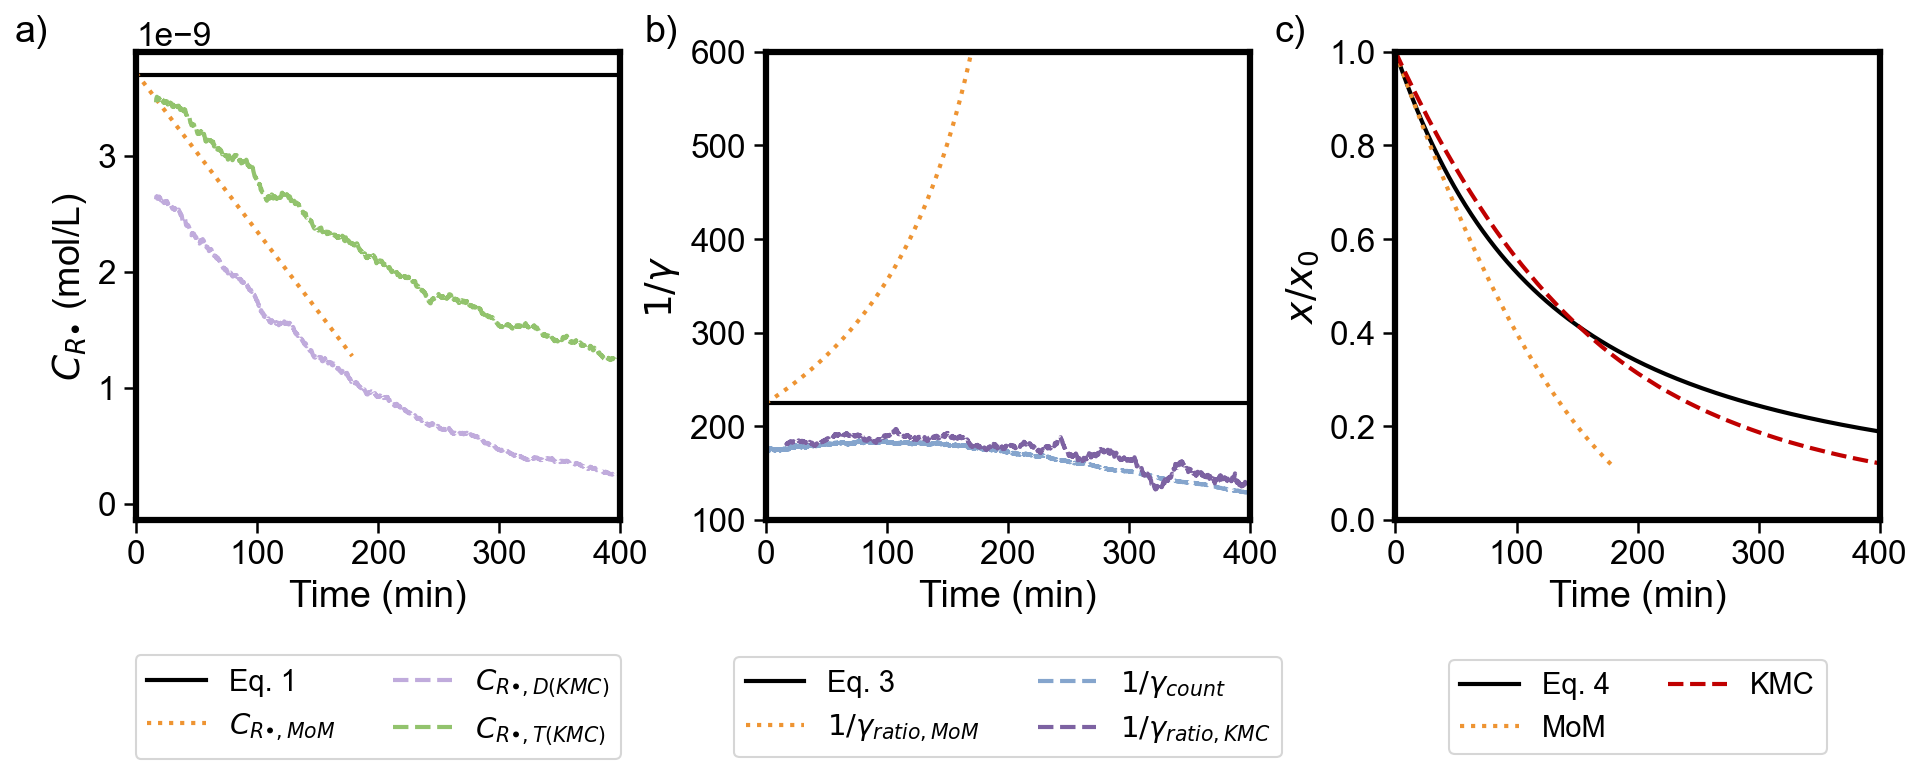

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(3*plotsize, 1.3*plotsize), 
                        gridspec_kw={'wspace': 0.3, 'hspace': 0.5})

# --- Plot 1: Radical Concentration ---
ax = axs[0]

ax.axhline(np.sqrt(kmc_data['kI'] * kmc_df['d0(t) (g/L)'].iloc[0] / kmc_data['kT'] / kmc_data['m0']),
           label=r'Eq. 1', linestyle='-', c='k')
ax.plot(mom_df['Time (min)'], mom_df["Radical Conc"],
        label=r'$C_{R•,MoM}$', c=cdict['orange'], linestyle=':')
ax.plot(kmc_df['Time (min)'], kmc_df["Radical Conc BS"].rolling(window=100).mean(),
        label=r'$C_{R•,D (KMC)}$', c=cdict['lightpurple'], linestyle='--')
ax.plot(kmc_df['Time (min)'], kmc_df["Radical Conc RR"].rolling(window=100).mean(),
        label=r'$C_{R•,T (KMC)}$', c=cdict['green'], linestyle='--')

ax.set_ylabel(r"$C_{R•}$ (mol/L)")
ax.set_xlabel("Time (min)")

# --- Plot 2: Zip Lengths ---
ax = axs[1]

x, y = downsample_plot_data(
    kmc_data['zip_length_df']['Zip End Time (s)'].to_numpy() / 60,
    kmc_data['zip_length_df']['Zip Length (#)'].to_numpy(),
    window=int(len(kmc_data['zip_length_df']) / 100)
)
ax.axhline(kmc_data['kD'] * np.sqrt(kmc_data['m0'] / (kmc_data['kT'] * kmc_data['kI'] * kmc_df['d0(t) (g/L)'].iloc[0])),
           label=r'Eq. 3', linestyle='-', c='k')
ax.plot(mom_df['Time (min)'], mom_df['Rp/Rt'],
        label=r'$1/{\gamma_{ratio,MoM}}$', c=cdict['orange'], linestyle=':')
ax.plot(x, y,
        label=r'$1/{\gamma_{count}}$', c=cdict['lightblue'], linestyle='--')
ax.plot(kmc_df['Time (min)'].iloc[1:], kmc_df['2a'].iloc[1:].rolling(window=100).mean(),
        label=r'$1/{\gamma_{ratio,KMC}}$', linestyle='--', c=cdict['purple2'])

ax.set_ylabel(r"$1/\gamma$")
ax.set_xlabel("Time (min)")
ax.set_ylim([100, 600])

# --- Plot 3: Decay (Normalized Mn) ---
ax = axs[2]

x0 = mom_df['Mn/Mn0 (DP)'].iloc[0]
d0 = mom_df['d0(t) (g/L)'].iloc[0]
inv_gamma = kmc_data['kD'] * np.sqrt(kmc_data['m0'] / (kmc_data['kT'] * kmc_data['kI'] * d0))

x = np.linspace(0.001, round(x0), round(x0))
t = (1/kmc_data['kI'] * (1/x - 1/x0 + 1/inv_gamma/2 * np.log((inv_gamma + 2*x0) / (inv_gamma + 2*x))))

ax.plot(t/60, x/x0,
        label=r'Eq. 4', linestyle='-', c='k')
ax.plot(mom_df['Time (min)'], mom_df["Mn/Mn0 (DP)"].rolling(window=1).mean() / 400,
        label=r'MoM', c=cdict['orange'], linestyle=':')
ax.plot(kmc_df['Time (min)'], kmc_df["Mn/Mn0 (DP)"].rolling(window=1).mean() / 400,
        label=r'KMC', c=cdict['red'], linestyle='--')

ax.set_ylim([0, 1])
ax.set_xlabel('Time (min)')
ax.set_ylabel(r'$x/x_0$')

for i in range(3):
    axs[i].set_xlim([0, 400])

create_inset_legend(axs, ncol=2, fontsize=14)
add_subplot_labels(axs, ['a)', 'b)', 'c)'])

fig.subplots_adjust(bottom=0.4)
plt.tight_layout()
plt.savefig("fig_pdfs/fig2_model_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 3: Radical Concentration Changes with Initial Chain Length

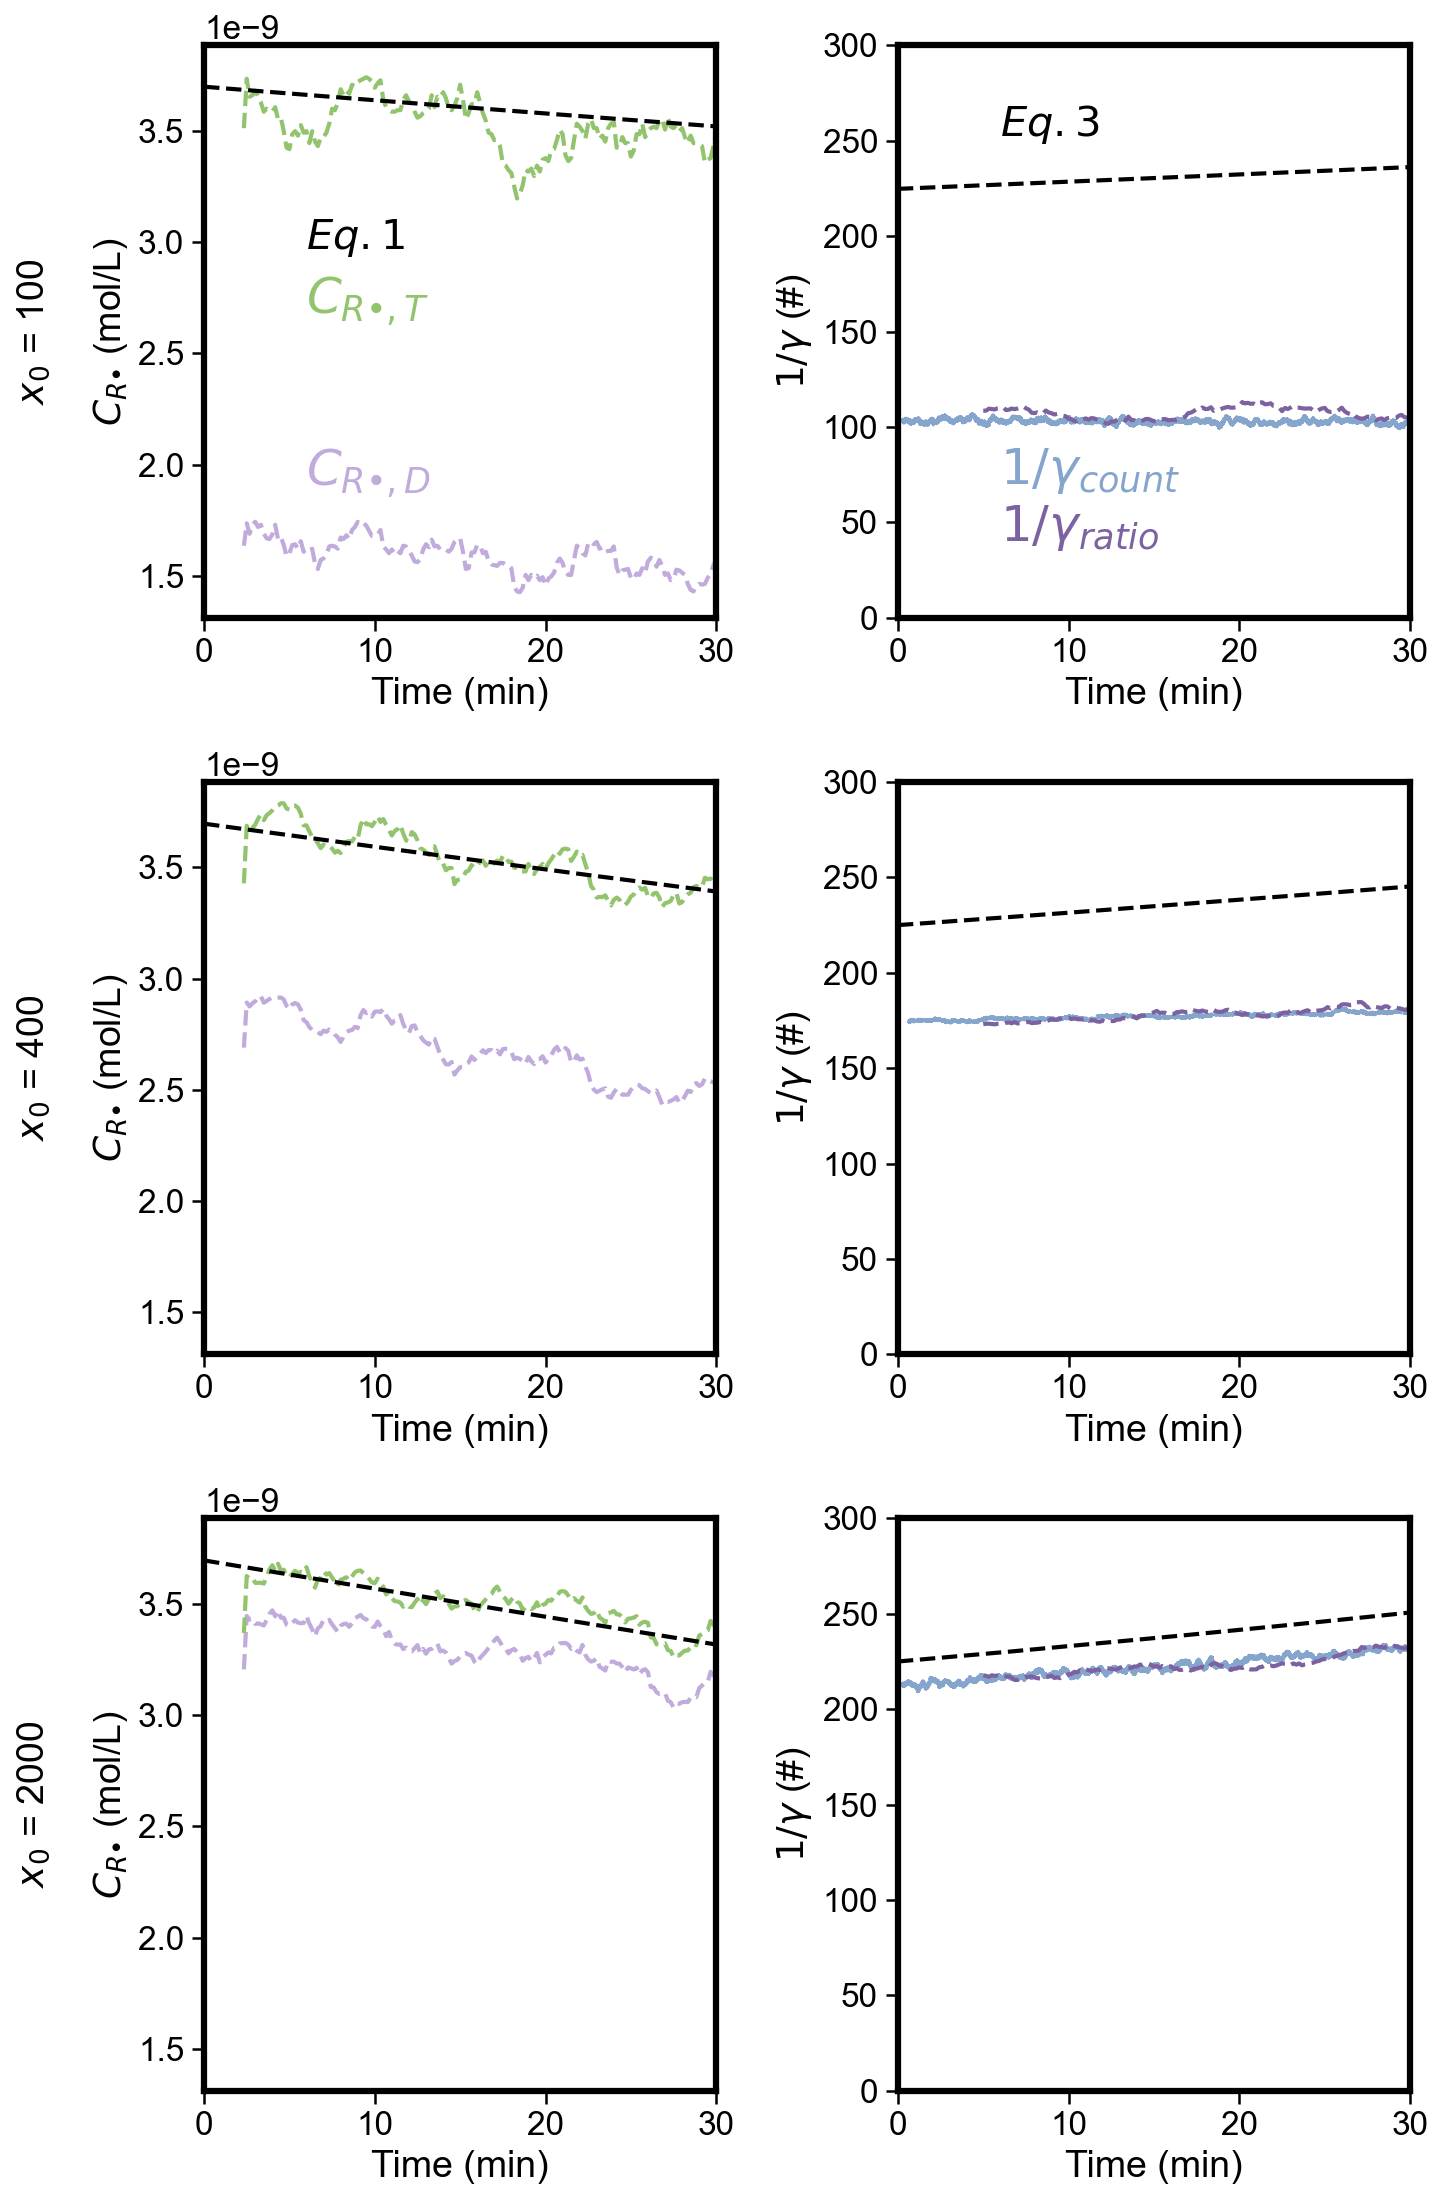

In [32]:
run_dpns = [100, 400, 2000]
fig, axs = plt.subplots(len(run_dpns), 2, figsize=(2*plotsize, len(run_dpns)*plotsize), 
                        tight_layout=True)

for i, dpn in enumerate(run_dpns):
    # Load data
    try:
        data = read_data(f"../kmc_src/spedup_cpp_files/T_260/run_{dpn}_more_chains")
    except:
        data = read_data(f'../kmc_src/spedup_cpp_files/T_260/run_{dpn}')
    df = process_data(data)

    # --- Left subplot: Radical Concentration vs Time ---
    timewindow = 15
    axs[i, 0].plot(df['Time (min)'], df["Radical Conc BS"].rolling(window=timewindow).mean(), 
                   label=r'$C_{R•,BS}$', c=cdict['lightpurple'], linestyle='--')
    axs[i, 0].plot(df['Time (min)'], df["Radical Conc RR"].rolling(window=timewindow).mean(), 
                   label=r'$C_{R•,RR}$', c=cdict['green'], linestyle='--')
    axs[i, 0].plot(df['Time (min)'], df["Radical Conc [Eq 10b] Mod"], 
                   label=r"$C_{R•,Boyd}$", c='k', linestyle='--')
    
    axs[i, 0].set_ylabel(r"$C_{R•}$ (mol/L)")
    axs[i, 0].set_xlabel("Time (min)")

    # --- Right subplot: Zip Length vs Time ---
    win = int(len(data['zip_length_df']['Zip Length (#)']) / 100)
    
    axs[i, 1].plot(df['Time (min)'], df['Corrected ZL'].rolling(window=1).mean(), 
                   label=r'$1/{\gamma_{Boyd}}$', linestyle='--', c='k')
    
    x, y = downsample_plot_data(
        data['zip_length_df']['Zip End Time (s)'].to_numpy() / 60,
        data['zip_length_df']['Zip Length (#)'].to_numpy(),
        window=win
    )
    axs[i, 1].plot(x, y, label=r'$1/{\gamma_{count}}$', c=cdict['lightblue'], linestyle='--')
    
    axs[i, 1].plot(df['Time (min)'].iloc[1:], df['2a'].iloc[1:].rolling(window=30).mean(), 
                   label=r'$1/{\gamma_{ratio}}$', linestyle='--', c=cdict['purple2'])
    
    axs[i, 1].set_ylabel(r"$1/\gamma$ (#)")
    axs[i, 1].set_xlabel("Time (min)")
    axs[i, 1].set_ylim(bottom=0, top=300)

# Set consistent xlim across all rows
for row in axs:
    row[0].set_xlim([0, 30])
    row[1].set_xlim([0, 30])

# Align y-limits within each column
align_subplot_limits(axs, axis='y')

# Add DPn labels on left side
for dpn, i in zip(run_dpns, range(len(run_dpns))):
    ylims = axs[i, 0].get_ylim()
    axs[i, 0].text(-10, (ylims[0] + ylims[1]) / 2, rf"$x_0$ = {dpn}", 
                   rotation=90, ha='center', va='center')

# Add legend annotations
axs[0, 0].text(0.2, 0.7, r'$Eq. 1$', transform=axs[0, 0].transAxes, 
               va='top', ha='left', c=cdict['black'], fontweight='bold', fontsize=20)
axs[0, 0].text(0.2, 0.6, r'$C_{R•,T}$', transform=axs[0, 0].transAxes, 
               va='top', ha='left', c=cdict['green'], fontweight='bold', fontsize=24)
axs[0, 0].text(0.2, 0.3, r'$C_{R•,D}$', transform=axs[0, 0].transAxes, 
               va='top', ha='left', c=cdict['lightpurple'], fontweight='bold', fontsize=24)

axs[0, 1].text(0.2, 0.9, r'$Eq. 3$', transform=axs[0, 1].transAxes, 
               va='top', ha='left', c=cdict['black'], fontweight='bold', fontsize=20)
axs[0, 1].text(0.2, 0.3, r'$1/\gamma_{count}$', transform=axs[0, 1].transAxes, 
               va='top', ha='left', c=cdict['lightblue'], fontweight='bold', fontsize=24)
axs[0, 1].text(0.2, 0.2, r'$1/\gamma_{ratio}$', transform=axs[0, 1].transAxes, 
               va='top', ha='left', c=cdict['purple2'], fontweight='bold', fontsize=24)

plt.tight_layout()
plt.savefig("fig_pdfs/fig3_x0_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 4: Parameter Space Exploration

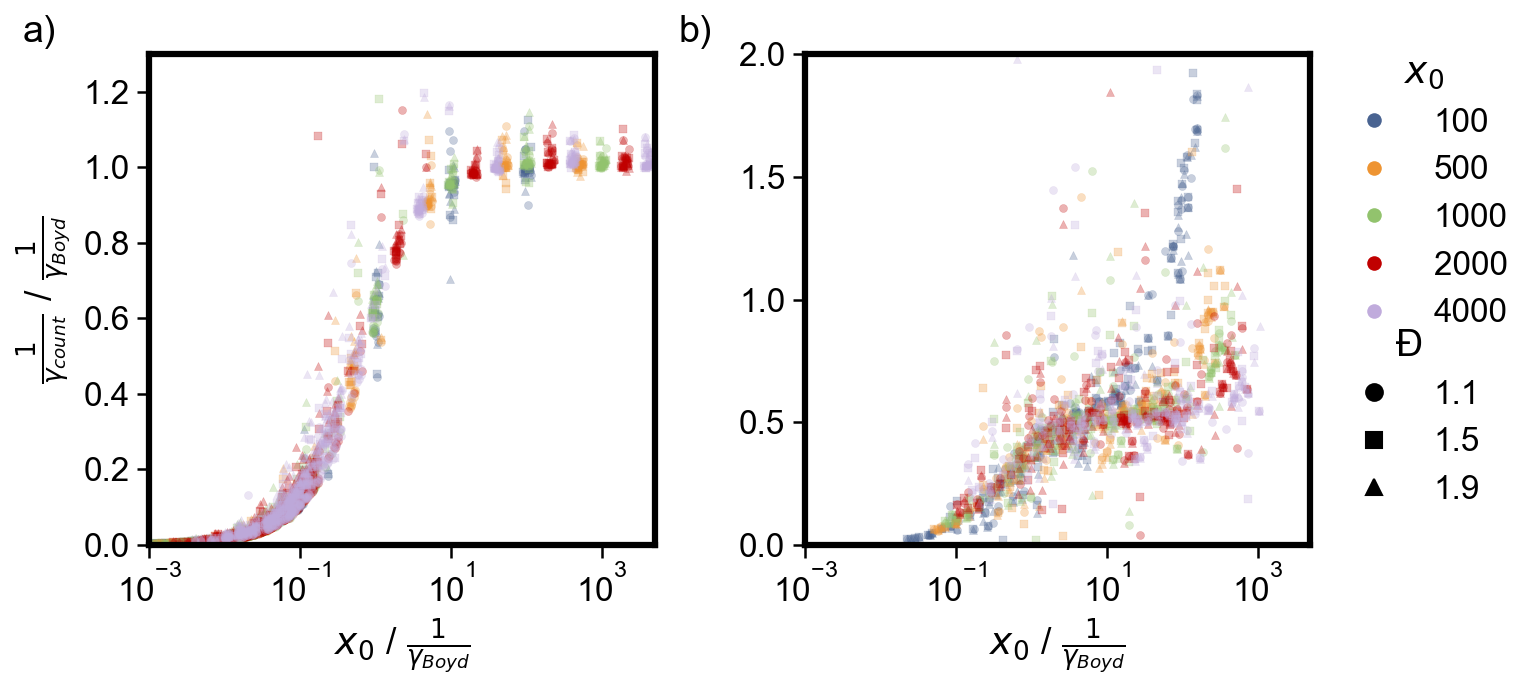

In [33]:
# Load and prepare data
df1 = pd.read_csv("../parameter_exploration/rs_methods_all_dpn_og_v1.csv")
df2 = pd.read_csv("../parameter_exploration/rs_methods_all_dpn_og_v2.csv")
df_kmc = pd.concat([df1, df2], ignore_index=True)
df_kmc['dpn'] = df_kmc['dpn_dir'].astype(str).str[4:].astype(float)
df_kmc['disp'] = df_kmc['kmc_run_dir'].astype(str).str[-3:].astype(float)
df_kmc['x-axis'] = df_kmc['dpn'] / df_kmc['zip_analytical']

for i in [1, 2, 3, 4]:
    df_kmc[f"ratio{i}"] = df_kmc[f"method_{i}_qty"] / df_kmc["zip_analytical"]

df_eci = pd.read_csv("../parameter_exploration/eci_summary_with_plots.csv")
df_eci['dpn'] = df_eci['x0'].astype(float)
df_eci['disp'] = df_eci['Dispersity'].astype(float)
df_eci['x-axis'] = df_eci['x0 / theory']
df_eci['ratio1'] = df_eci['actual / theory']

# Setup
x0_list = [100, 500, 1000, 2000, 4000]
disp_list = [1.1, 1.5, 1.9]

color_map = {x0: c for x0, c in zip(x0_list, 
    [cdict['darkblue'], cdict['orange'], cdict['green'], cdict['red'], cdict['lightpurple']])}
marker_map = {1.1: "o", 1.5: "s", 1.9: "^"}

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(2.25*plotsize, plotsize))

# Plot KMC data (left)
ax = axes[0]
for x0 in x0_list:
    for disp in disp_list:
        mask = (df_kmc['dpn'] == x0) & (df_kmc['disp'] == disp) & (df_kmc['ratio1'] < 1.2)
        if mask.any():
            ax.scatter(df_kmc.loc[mask, 'x-axis'], df_kmc.loc[mask, 'ratio1'],
                      color=color_map[x0], marker=marker_map[disp], alpha=0.3,
                      s=plotsize*3, linewidths=0.2)

ax.set_xscale('log')
ax.set_xlabel(r"$x_0$ / $\frac{1}{\gamma_{Boyd}}$")
ax.set_ylabel(r"$\frac{1}{\gamma_{count}}$ / $\frac{1}{\gamma_{Boyd}}$")
ax.set_ylim([0, 1.3])
ax.set_xlim([0.001, 5E3])

# Plot ECI data (right)
ax = axes[1]
for x0 in x0_list:
    for disp in disp_list:
        mask = (df_eci['dpn'] == x0) & (df_eci['disp'] == disp) & (df_eci['N rows'] < 5E5)
        if mask.any():
            ax.scatter(df_eci.loc[mask, 'x-axis'], df_eci.loc[mask, 'ratio1'],
                      color=color_map[x0], marker=marker_map[disp], alpha=0.3,
                      s=plotsize*3, linewidths=0.2)

ax.set_xscale('log')
ax.set_xlabel(r"$x_0$ / $\frac{1}{\gamma_{Boyd}}$")
ax.set_ylim([0, 2])
ax.set_xlim([0.001, 5E3])

# Create custom legend
color_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[x0], 
                       markersize=8, label=f"{x0}") for x0 in x0_list]
marker_handles = [Line2D([0], [0], marker=marker_map[disp], color='k', linestyle='None', 
                        markersize=8, label=f"{disp}") for disp in disp_list]

fig.legend(handles=color_handles, title=r'$x_0$', loc='center left', 
          bbox_to_anchor=(0.8, 0.7), ncol=1)
fig.legend(handles=marker_handles, title="Đ", loc='center left', 
          bbox_to_anchor=(0.8, 0.4), ncol=1)

add_subplot_labels(axes, ['a)', 'b)'])

plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.savefig("fig_pdfs/fig4_param_space_search.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 5: ECI special cases

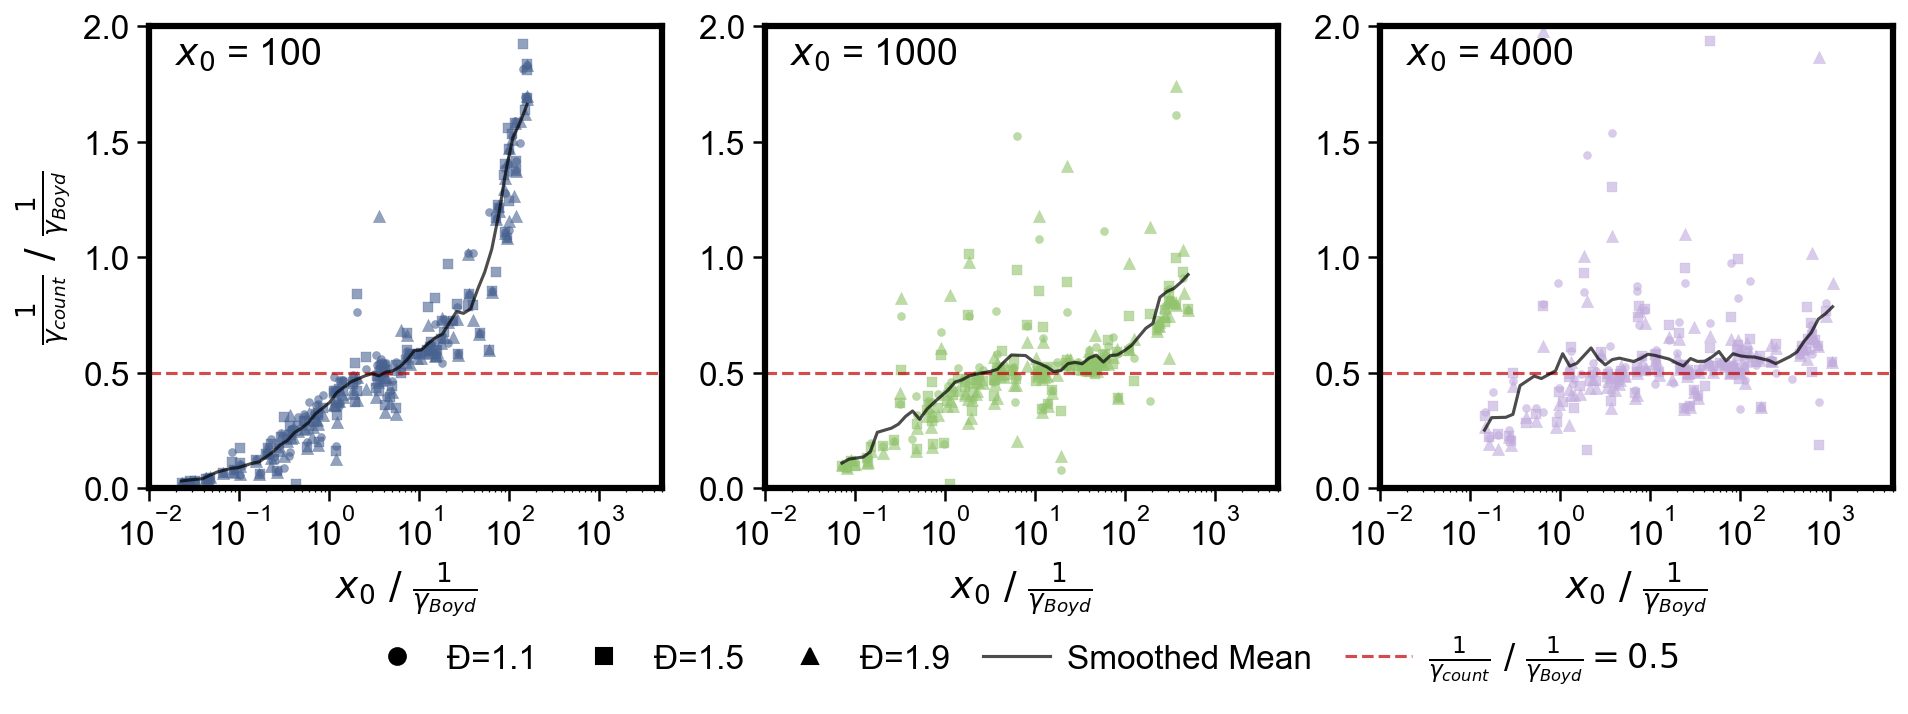

In [34]:
# Font sizes
LABEL_SIZE = 18
TICK_SIZE = 16
LEGEND_SIZE = 16
TITLE_SIZE = 18

# Marker sizes by dispersity - more distinct
marker_size_map = {1.1: plotsize*3, 1.5: plotsize*5, 1.9: plotsize*7}

fig, axes_grid = plt.subplots(1, 3, figsize=(3*plotsize, 0.8*plotsize))

legend_handles = []  # collect handles for universal legend

for idx, x0 in enumerate([100, 1000, 4000]):
    ax = axes_grid[idx]

    for disp in disp_list:
        mask = (df_eci['dpn'] == x0) & (df_eci['disp'] == disp) & (df_eci['N rows'] < 5E5)
        if not mask.any():
            continue
        x = df_eci.loc[mask, 'x-axis']
        y = df_eci.loc[mask, 'ratio1']
        sc = ax.scatter(
            x, y,
            color=color_map[x0],
            marker=marker_map[disp],
            alpha=0.6,
            s=marker_size_map[disp],
            linewidths=0.2,
            label=f"Đ={disp}"
        )
        # Only collect legend handles from first panel to avoid duplicates
        if idx == 0:
            legend_handles.append(sc)

    # Add average line across all dispersities
    mask_all = (df_eci['dpn'] == x0) & (df_eci['N rows'] < 5E5) & (df_eci['ratio1'] < 2)
    if mask_all.any():
        x_all = df_eci.loc[mask_all, 'x-axis'].copy()
        y_all = df_eci.loc[mask_all, 'ratio1'].copy()

        n_bins = max(50, len(x_all) // 15)
        x_all_log = np.log10(x_all)
        bin_edges = np.linspace(x_all_log.min(), x_all_log.max(), n_bins)
        bin_indices = np.digitize(x_all_log, bin_edges)

        bin_centers = []
        bin_means = []
        for bin_idx in np.unique(bin_indices):
            mask_bin = (bin_indices == bin_idx)
            if mask_bin.sum() > 0:
                bin_centers.append(10 ** bin_edges[bin_idx - 1])
                bin_means.append(y_all[mask_bin].mean())

        if bin_centers:
            sorted_idx = np.argsort(bin_centers)
            bin_centers_sorted = np.array(bin_centers)[sorted_idx]
            bin_means_sorted = np.array(bin_means)[sorted_idx]
            smooth_means = pd.Series(bin_means_sorted).rolling(
                window=5, center=True, min_periods=1
            ).mean().values
            line, = ax.plot(
                bin_centers_sorted, smooth_means,
                color='k', alpha=0.7, linewidth=1.5,
                label='Smoothed Mean', zorder=10
            )
            # Collect smoothed mean handle only once
            if idx == 0:
                legend_handles.append(line)

    ax.set_xscale('log')
    ax.set_xlabel(r"$x_0\ /\ \frac{1}{\gamma_{Boyd}}$", fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)

    if idx == 0:
        ax.set_ylabel(
            r"$\frac{1}{\gamma_{count}}\ /\ \frac{1}{\gamma_{Boyd}}$",
            fontsize=LABEL_SIZE
        )

    ax.set_ylim([0, 2])
    ax.set_xlim([0.01, 5E3])

    # Panel title inside bottom right to avoid legend overlap
    ax.text(
        0.05, 0.9, f"$x_0$ = {x0}",
        transform=ax.transAxes,
        fontsize=TITLE_SIZE, 
        va='bottom', ha='left'
    )

    # Reference line at 0.5 with label
    line = ax.axhline(0.5, alpha=0.7, color=cdict['red'], linestyle='--', linewidth=1.5, label=r"$\frac{1}{\gamma_{count}}\ /\ \frac{1}{\gamma_{Boyd}} = 0.5$")
    if idx == 0:
        legend_handles.append(line)

    # No per-panel legends
    ax.legend().set_visible(False)

# Universal legend below middle panel
from matplotlib.lines import Line2D

# Replace scatter handles with black marker-only handles for legend
black_disp_handles = [
    Line2D([0], [0], marker=marker_map[disp], color='w', 
           markerfacecolor='k', markeredgecolor='k',
           markersize=8, label=f"Đ={disp}")
    for disp in disp_list
]

# Rebuild legend_handles: black dispersity markers + smoothed mean + reference line
final_legend_handles = black_disp_handles + [h for h in legend_handles if not isinstance(h, PathCollection)]

axes_grid[1].legend(
    handles=final_legend_handles,
    fontsize=LEGEND_SIZE,
    framealpha=0.8,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=len(final_legend_handles),
    handletextpad=0.5,
    columnspacing=1.0
)
# plt.tight_layout()
plt.savefig("fig_pdfs/fig5_eci_x0.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 6: Best-Fit Kinetics 

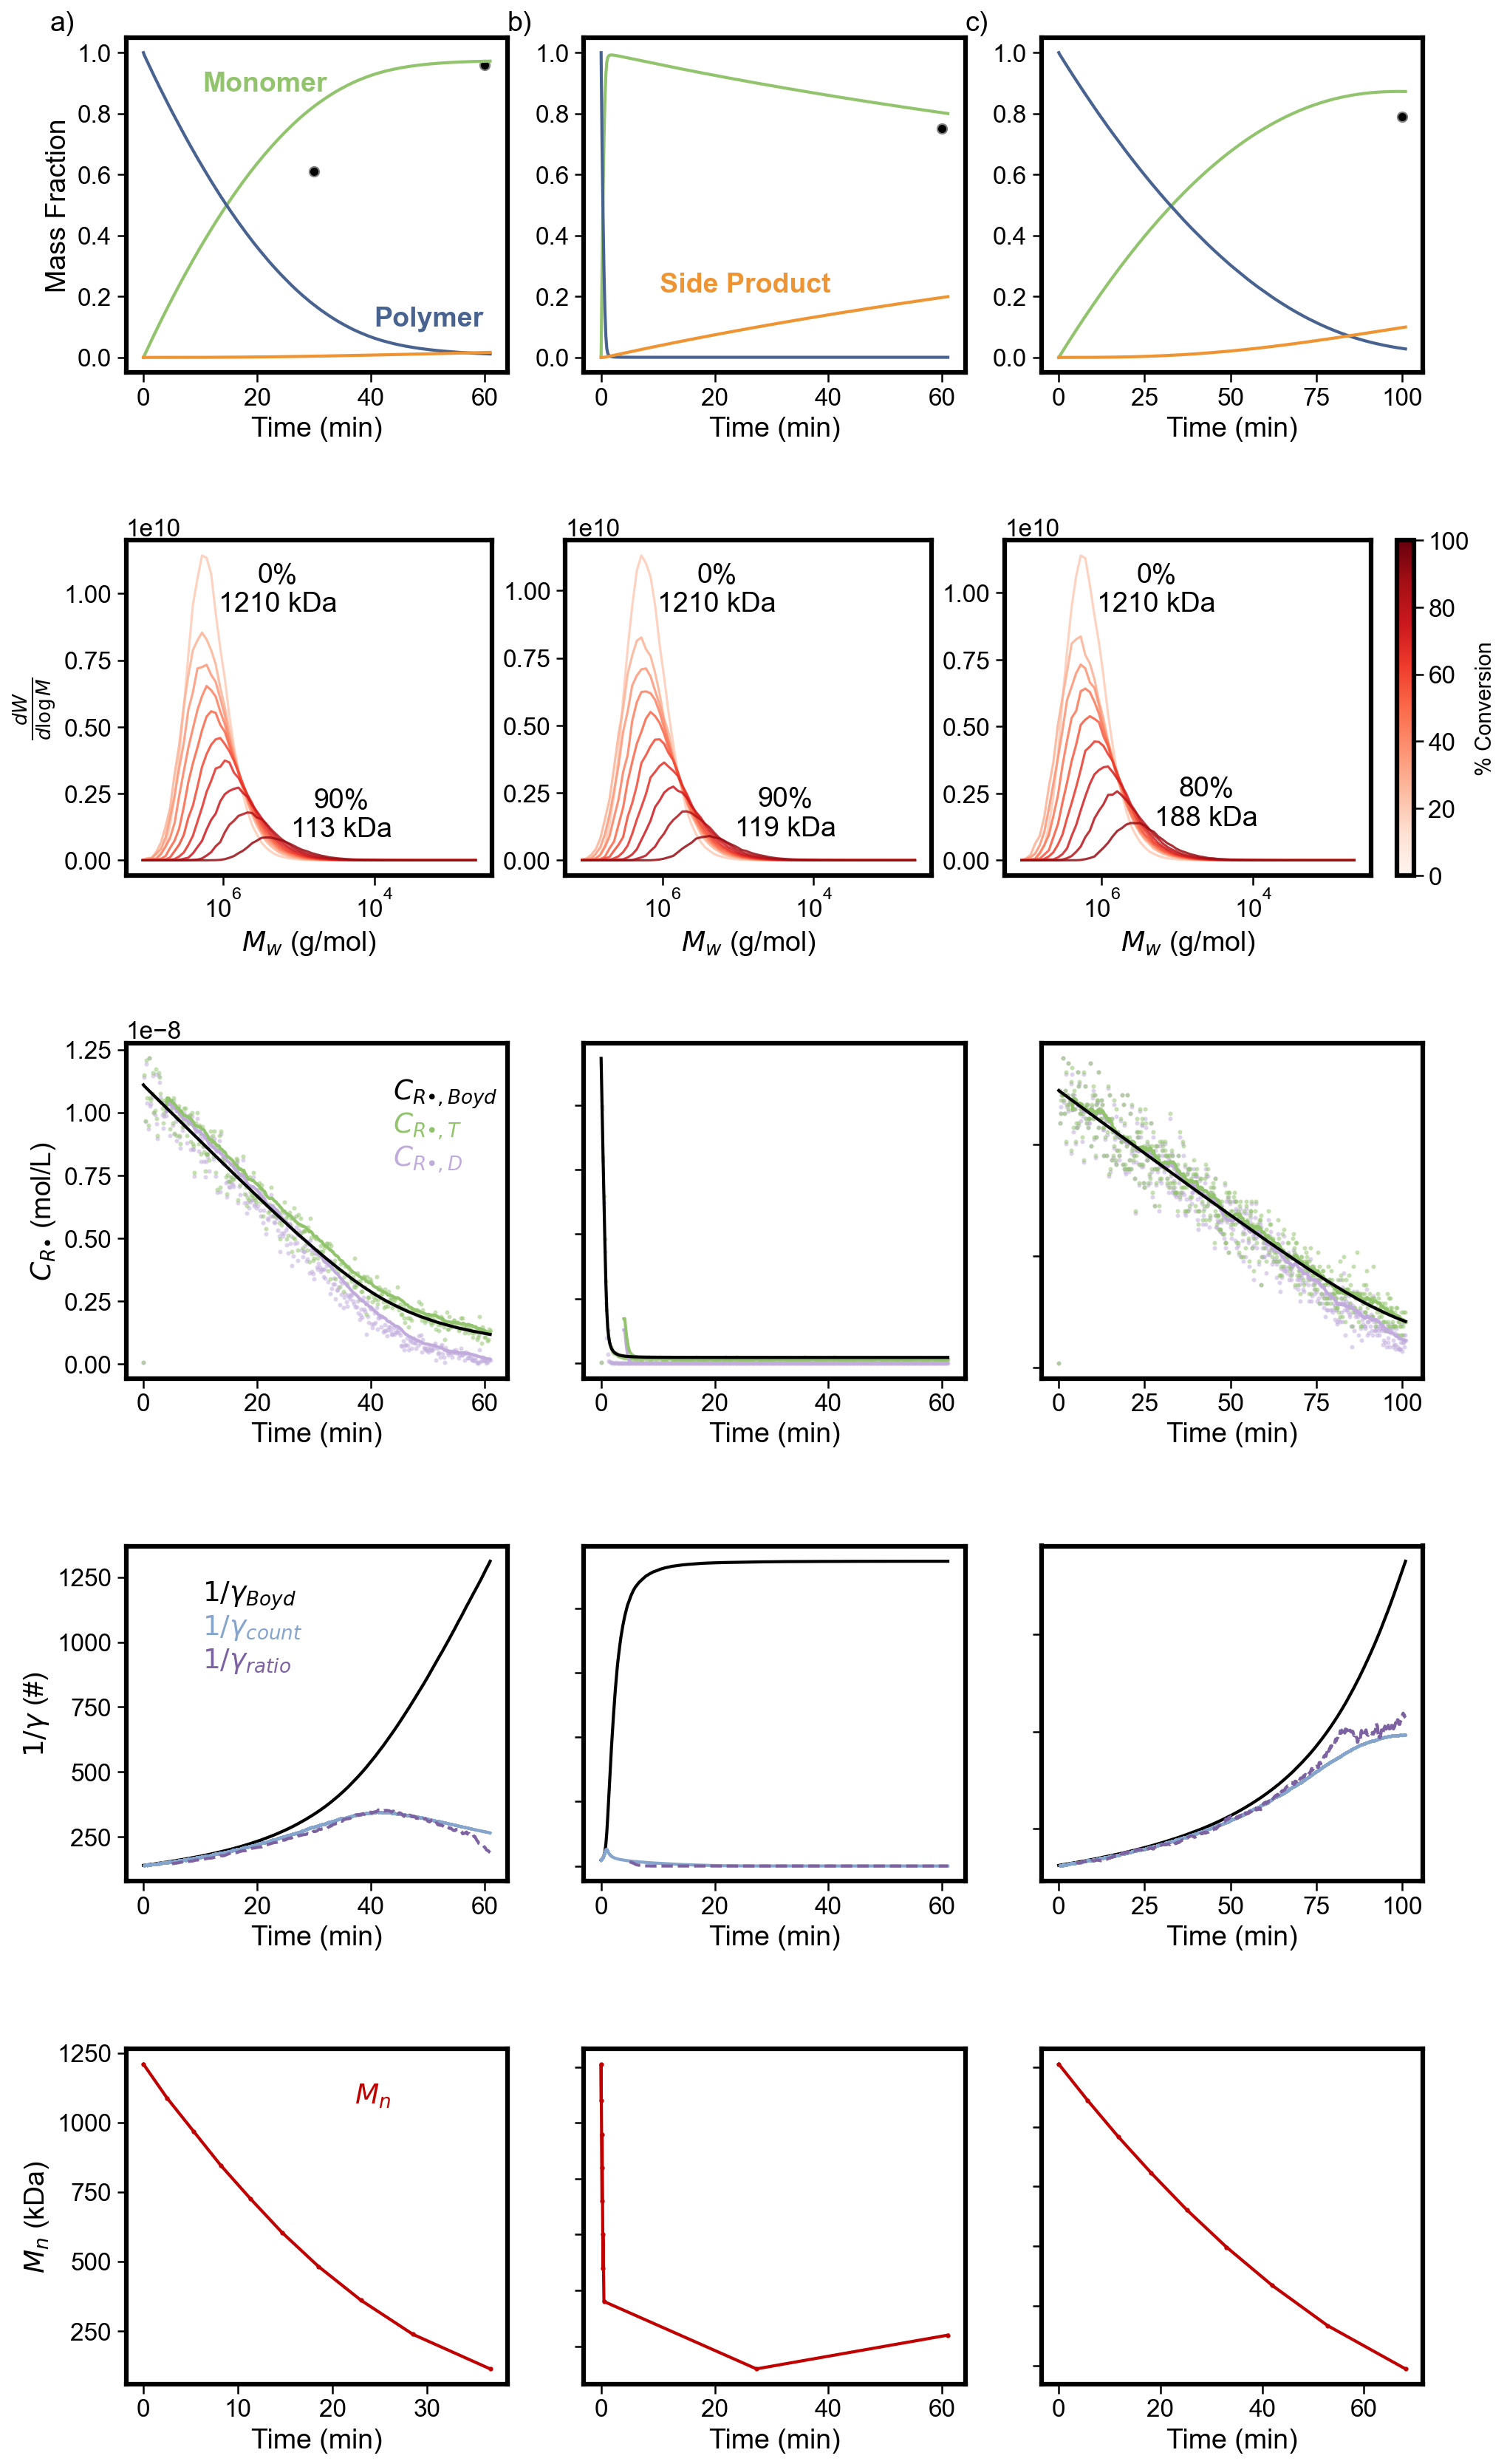

In [35]:
data_250 = read_data(f'../kmc_src/polyME_cpp_files_conv/run_conv_4_2_26/run_025_T_250')
df_250 = process_data(data_250)

data_300 = read_data(f'../kmc_src/polyME_cpp_files_conv/run_conv_4_2_26/run_025_T_300')
df_300 = process_data(data_300)

data_high_rho = read_data(f'../kmc_src/polyME_cpp_files_conv/run_conv_4_2_26/run_025_T_250_high_rho')
df_high_rho = process_data(data_high_rho)

case_dict = {
    r"250": [0, data_250, df_250, r"T = 250 $\degree$C, $\rho$ = 5 g/L"],
    r"300": [1, data_300, df_300, r"T = 300 $\degree$C, $\rho$ = 5 g/L"],
    r"250_high_rho": [2, data_high_rho, df_high_rho, r"T = 250 $\degree$C   $\rho$ = 25 g/L"],
}

fig, ax = plt.subplots(5, len(case_dict), figsize=(plotsize * len(case_dict)+0.1, plotsize * 5.5))
plt.subplots_adjust(hspace=0.5)

legend_handles = [[], [], [], [], []]
legend_labels = [[], [], [], [], []]

# Precompute global bin edges across all cases for consistent MWD x-axis
all_weights = []
for name, [i, data, df, label] in case_dict.items():
    for path in sorted(data['chain_weight_paths']):
        weight_df = pd.read_csv(path)
        all_weights.extend(weight_df['chain_weight_g_mol'].values)
global_min = min(all_weights)
global_max = max(all_weights)
bins = np.logspace(np.log10(global_min), np.log10(global_max), num=75)

for name, [i, data, df, label] in case_dict.items():

    # Suppress y-axis labels on non-leftmost panels — inside loop, correct i
    if i == 0:
        ax[0][i].set_ylabel("Mass Fraction")
        ax[1][i].set_ylabel(r"$\frac{dW}{d\log M}$", rotation='vertical')
        ax[2][i].set_ylabel(r"$C_{R•}$ (mol/L)")
        ax[3][i].set_ylabel(r"$1/\gamma$ (#)")
        ax[4][i].set_ylabel(r"$M_n$ (kDa)")
    else:
        for row in range(5):
            ax[row][i].set_ylabel('')
        ax[2][i].tick_params(labelleft=False)
        ax[3][i].tick_params(labelleft=False)
        ax[4][i].tick_params(labelleft=False)

    # Row 0: Mass yields
    try:
        l2, = ax[0][i].plot(df['Time (min)'], df['Monomer Wt Fraction'], label='Monomer', c=cdict['green'])
    except:
        l2, = ax[0][i].plot(df['Time (min)'], df['Monomer Conversion'], label='Monomer', c=cdict['green'])
    l3, = ax[0][i].plot(df['Time (min)'], df['Polymer Wt Fraction'], label='Polymer', c=cdict['darkblue'])
    try:
        l4, = ax[0][i].plot(df['Time (min)'], df['Side Product Wt Fraction'], label='Side Product', c=cdict['orange'])
    except:
        l4, = ax[0][i].plot(df['Time (min)'], df['Side Product Wt Fraction'], label='Side Product', c=cdict['orange'])
    ax[0][i].set_xlabel("Time (min)")
    if i == 0:
        legend_handles[0] = [l2, l3, l4]
        legend_labels[0] = ['Monomer', 'Polymer', 'Side Product']

    # Experimental points
    if i == 0:
        ax[0][i].scatter([30, 60], [.61, .96], s=40, edgecolor='gray', c='k')
    if i == 1:
        ax[0][i].scatter([60], [.75], s=40, edgecolor='gray', c='k')
    if i == 2:
        ax[0][i].scatter([100], [.79], s=40, edgecolor='gray', c='k')

    # Row 1: MWD with color gradient
    conv_col = 'Monomer Conversion' if 'Monomer Conversion' in df.columns else 'Monomer Wt Fraction'
    mwd_times = []
    mwd_paths = sorted(data['chain_weight_paths'])
    n_mwd = len(mwd_paths)
    mwd_colors = plt.cm.Reds(np.linspace(0.2, 0.9, n_mwd))

    for path_idx, path in enumerate(mwd_paths):
        weight_df = pd.read_csv(path)
        molecular_weights = weight_df['chain_weight_g_mol']
        Mn = np.mean(molecular_weights)

        match_t = re.search(r'chain_weights_(\d+)(?:pct_conversion|_mins)', path)
        if match_t:
            x_val_t = int(match_t.group(1))
            if 'pct_conversion' in path:
                idx_t = (df[conv_col] - x_val_t / 100).abs().idxmin()
                if i == 0: mwd_times.append(df.loc[idx_t, 'Time (min)'])
            else:
                if i == 0: mwd_times.append(x_val_t)

        hist, bin_edges = np.histogram(molecular_weights, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        y_values = bin_centers * hist
        y_values_normalized = y_values

        line, = ax[1][i].plot(bin_centers, y_values_normalized,
                                linewidth=1.5,
                                c=mwd_colors[path_idx],
                                alpha=0.85)

        # Label only first and last curve
        if (path_idx == 0 or path_idx == n_mwd - 1) and match_t:
            peak_idx = np.argmax(y_values_normalized)
            label_str = (f"{x_val_t}%\n{Mn/1000:.0f} kDa" if 'pct_conversion' in path
                            else f"{x_val_t} min\n{Mn/1000:.0f} kDa")
            ax[1][i].text(bin_centers[peak_idx]*0.1, y_values_normalized[peak_idx] *0.8,
                            label_str, ha='center', va='bottom',
                            c='k')

        if i == 0:
            legend_handles[1].append(line)

    ax[1][i].set_xscale('log')
    ax[1][i].set_xlabel(r"$M_w$ (g/mol)")
    ax[1][i].invert_xaxis()

    # Row 4: Mn decay
    mn_times = []
    mn_values = []
    for path in sorted(data['chain_weight_paths']):
        match = re.search(r'chain_weights_(\d+)(?:pct_conversion|_mins)', path)
        if match:
            x_val = int(match.group(1))
            if 'pct_conversion' in path:
                conv_frac = x_val / 100
                idx = (df[conv_col] - conv_frac).abs().idxmin()
                t = df.loc[idx, 'Time (min)']
            else:
                t = x_val
            weight_df = pd.read_csv(path)
            mn_values.append(np.mean(weight_df['chain_weight_g_mol']) / 1000)
            mn_times.append(t)
    mn_times, mn_values = zip(*sorted(zip(mn_times, mn_values)))
    l_mn, = ax[4][i].plot(mn_times, mn_values, 'o-', linewidth=2, c=cdict['red'])
    ax[4][i].set_xlabel('Time (min)')
    if i == 0:
        legend_handles[4].append(l_mn)

    # Row 2: Radical concentration
    timewindow = 25
    ax[2][i].scatter(df['Time (min)'], df["Radical Conc BS"], c=cdict['lightpurple'], alpha=0.4, label='_nolegend_')
    l1, = ax[2][i].plot(df['Time (min)'], df["Radical Conc BS"].rolling(window=timewindow).mean(),
                        label=r'$C_{R•,D}$', c=cdict['lightpurple'])
    ax[2][i].scatter(df['Time (min)'], df["Radical Conc RR"], c=cdict['green'], alpha=0.4, label='_nolegend_')
    l2, = ax[2][i].plot(df['Time (min)'], df["Radical Conc RR"].rolling(window=timewindow).mean(),
                        label=r'$C_{R•,T}$', c=cdict['green'])
    l3, = ax[2][i].plot(df['Time (min)'], df["Radical Conc [Eq 10b] Mod"],
                        label=r"$C_{R•,Boyd}$", c='k')
    ax[2][i].set_xlabel("Time (min)")
    if i == 0:
        legend_handles[2] = [l1, l2, l3]
        legend_labels[2] = [r'$C_{R•,D}$', r'$C_{R•,T}$', r"$C_{R•,Boyd}$"]

    # Row 3: Zip length
    win = int(len(data['zip_length_df']['Zip Length (#)']) / 100)
    l1, = ax[3][i].plot(df['Time (min)'], df['Corrected ZL'].rolling(window=1).mean(),
                        label=r'$1/\gamma_{Boyd}$', c='k')
    l2, = ax[3][i].plot(data['zip_length_df']['Zip End Time (s)'] / 60,
                        data['zip_length_df']['Zip Length (#)'].rolling(window=win).mean(),
                        label=r'$1/\gamma_{count}$', c=cdict['lightblue'])
    l3, = ax[3][i].plot(df['Time (min)'].iloc[1:], df['2a'].iloc[1:].rolling(window=30).mean(),
                        label=r'$1/\gamma_{ratio}$', linestyle='--', c=cdict['purple2'])
    ax[3][i].set_xlabel("Time (min)")
    if i == 0:
        legend_handles[3] = [l1, l2, l3]
        legend_labels[3] = [r'$1/\gamma_{Boyd}$', r'$1/\gamma_{count}$', r'$1/\gamma_{ratio}$']

# Colorbar for MWD gradient — outside loop, after all panels drawn
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[1, :], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('% Conversion' if 'pct_conversion' in sorted(data_250['chain_weight_paths'])[0]
                else 'Time (min)', fontsize=14)

# Subplot labels
ax[0][0].text(-0.2, 1.08, 'a)', transform=ax[0][0].transAxes, va='top', ha='left')
ax[0][1].text(-0.2, 1.08, 'b)', transform=ax[0][1].transAxes, va='top', ha='left')
ax[0][2].text(-0.2, 1.08, 'c)', transform=ax[0][2].transAxes, va='top', ha='left')

# Inline labels row 0
ax[0][0].text(0.65, 0.2, "Polymer", transform=ax[0][0].transAxes, va='top', ha='left', c=cdict['darkblue'], fontweight='bold')
ax[0][0].text(0.2, 0.9, "Monomer", transform=ax[0][0].transAxes, va='top', ha='left', c=cdict['green'], fontweight='bold')
ax[0][1].text(0.2, 0.3, "Side Product", transform=ax[0][1].transAxes, va='top', ha='left', c=cdict['orange'], fontweight='bold')

# Inline labels row 2
ax[2][0].text(0.7, 0.9, r'$C_{R•,Boyd}$', transform=ax[2][0].transAxes, va='top', ha='left', c=cdict['black'], fontweight='bold')
ax[2][0].text(0.7, 0.8, r'$C_{R•,T}$', transform=ax[2][0].transAxes, va='top', ha='left', c=cdict['green'], fontweight='bold')
ax[2][0].text(0.7, 0.7, r'$C_{R•,D}$', transform=ax[2][0].transAxes, va='top', ha='left', c=cdict['lightpurple'], fontweight='bold')

# Inline labels row 3
ax[3][0].text(0.2, 0.9, r'$1/\gamma_{Boyd}$', transform=ax[3][0].transAxes, va='top', ha='left', c=cdict['black'], fontweight='bold')
ax[3][0].text(0.2, 0.8, r'$1/\gamma_{count}$', transform=ax[3][0].transAxes, va='top', ha='left', c=cdict['lightblue'], fontweight='bold')
ax[3][0].text(0.2, 0.7, r'$1/\gamma_{ratio}$', transform=ax[3][0].transAxes, va='top', ha='left', c=cdict['purple2'], fontweight='bold')

# Inline label row 4
ax[4][0].text(0.6, 0.9, r'$M_n$', transform=ax[4][0].transAxes, va='top', ha='left', c=cdict['red'], fontweight='bold')

plt.savefig(f"fig_pdfs/fig6_kinetics.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figures for SI

In [36]:
df = pd.read_csv("../kmc_src/polyME_fit/fitting_results.csv")

df['log_AD'] = np.log10(df['A_D'])
df['log_ASR'] = np.log10(df['A_SR'])
best = df.loc[df['total_sse'].idxmin()]

cmap_contour = mcolors.LinearSegmentedColormap.from_list(
    'blues_custom', [cdict['green'], cdict['lightgreen'], cdict['yellow'], cdict['orange'], cdict['red']]
)

cmap_scatter = mcolors.LinearSegmentedColormap.from_list(
    'plasma_custom', [cdict['green'], cdict['lightblue'], cdict['purple']]
)

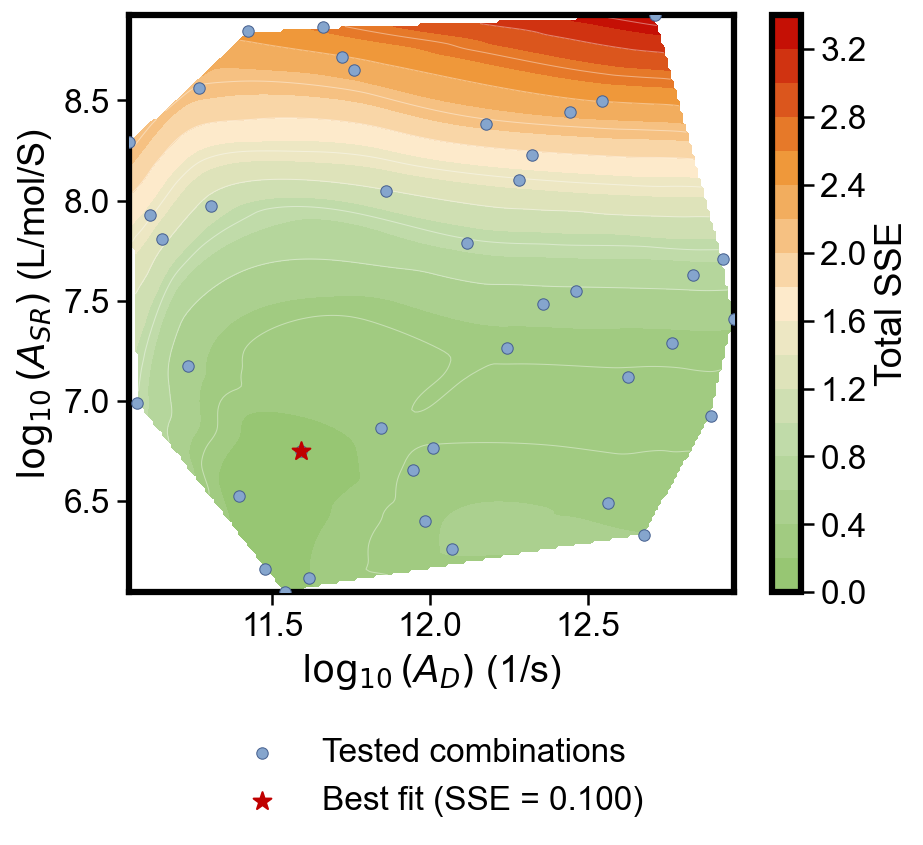

In [37]:
fig, ax = plt.subplots(figsize=(plotsize*1.3, plotsize))

xi = np.linspace(df['log_AD'].min(), df['log_AD'].max(), 200)
yi = np.linspace(df['log_ASR'].min(), df['log_ASR'].max(), 200)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((df['log_AD'], df['log_ASR']), df['total_sse'], (xi, yi), method='cubic')

contf = ax.contourf(xi, yi, zi, levels=20, cmap=cmap_contour)
cont  = ax.contour(xi, yi, zi, levels=10, colors='white', linewidths=0.5, alpha=0.4)
cbar  = fig.colorbar(contf, ax=ax)
cbar.set_label('Total SSE')

ax.scatter(df['log_AD'], df['log_ASR'], c=cdict['lightblue'], s=30, zorder=5,
           edgecolors=cdict['darkblue'], linewidths=0.5, label='Tested combinations')
ax.scatter(best['log_AD'], best['log_ASR'], c=cdict['red'], s=80, zorder=6,
           marker='*', label=f'Best fit (SSE = {best["total_sse"]:.3f})')

ax.set_xlabel(r'$\log_{10}(A_D)$ (1/s)')
ax.set_ylabel(r'$\log_{10}(A_{SR})$ (L/mol/S)')
ax.legend(bbox_to_anchor=(0.9,-0.2))
# plt.tight_layout()
plt.savefig('fig_pdfs/figS6_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

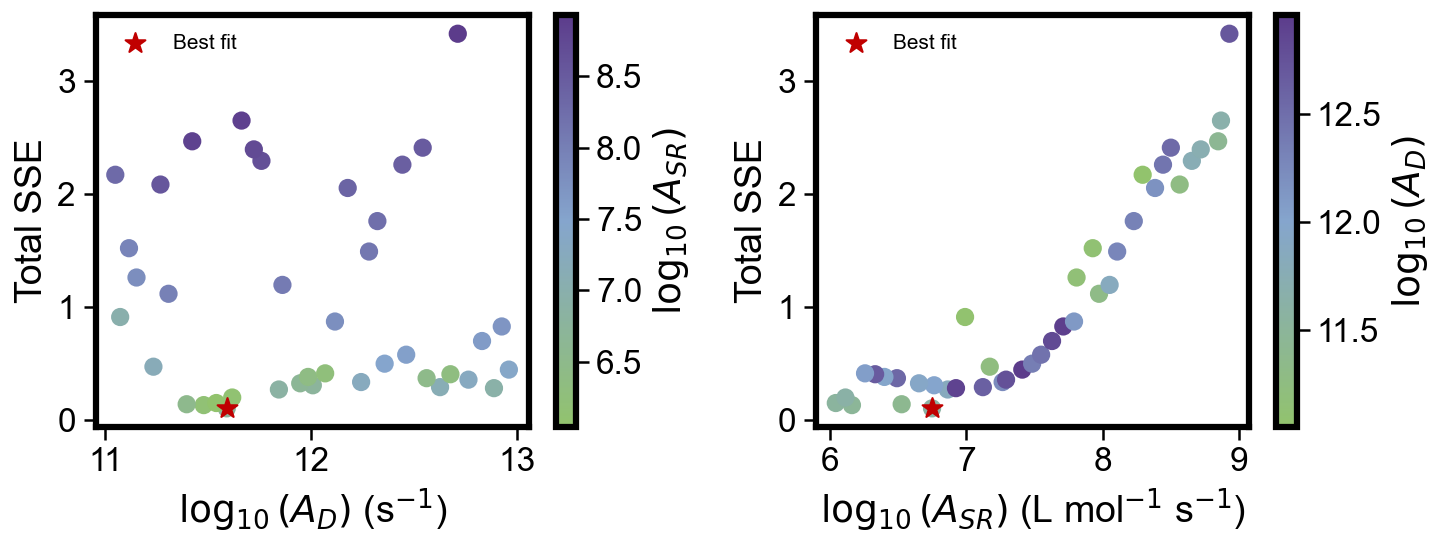

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(plotsize * 2, plotsize*0.8))

sc1 = axes[0].scatter(df['log_AD'], df['total_sse'],
                      c=df['log_ASR'], cmap=cmap_scatter, s=60)
axes[0].scatter(best['log_AD'], best['total_sse'], c=cdict['red'], s=100,
                marker='*', zorder=5, label='Best fit')
fig.colorbar(sc1, ax=axes[0], label=r'$\log_{10}(A_{SR})$')
axes[0].set_xlabel(r'$\log_{10}(A_D)$ (s$^{-1}$)')
axes[0].set_ylabel('Total SSE')
axes[0].legend(fontsize=10)

sc2 = axes[1].scatter(df['log_ASR'], df['total_sse'],
                      c=df['log_AD'], cmap=cmap_scatter, s=60)
axes[1].scatter(best['log_ASR'], best['total_sse'], c=cdict['red'], s=100,
                marker='*', zorder=5, label='Best fit')
fig.colorbar(sc2, ax=axes[1], label=r'$\log_{10}(A_D)$')
axes[1].set_xlabel(r'$\log_{10}(A_{SR})$ (L mol$^{-1}$ s$^{-1}$)')
axes[1].set_ylabel('Total SSE')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig_pdfs/figS7_SSE.pdf', dpi=300, bbox_inches='tight')
plt.show()

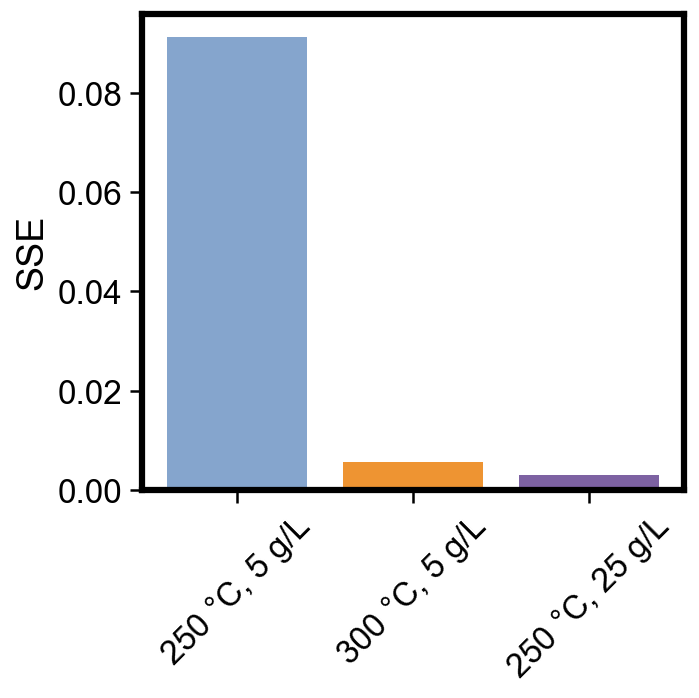

In [39]:
fig, ax = plt.subplots(figsize=(plotsize, plotsize))

conditions = ['250 °C, 5 g/L', '300 °C, 5 g/L', '250 °C, 25 g/L']
sse_vals   = [best['sse_T_250'], best['sse_T_300'], best['sse_T_250_high_rho']]
bar_colors = [cdict['lightblue'], cdict['orange'], cdict['purple2']]

bars = ax.bar(conditions, sse_vals, color=bar_colors)
ax.set_ylabel('SSE')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_pdfs/figS8_SSE.pdf', dpi=300, bbox_inches='tight')
plt.show()

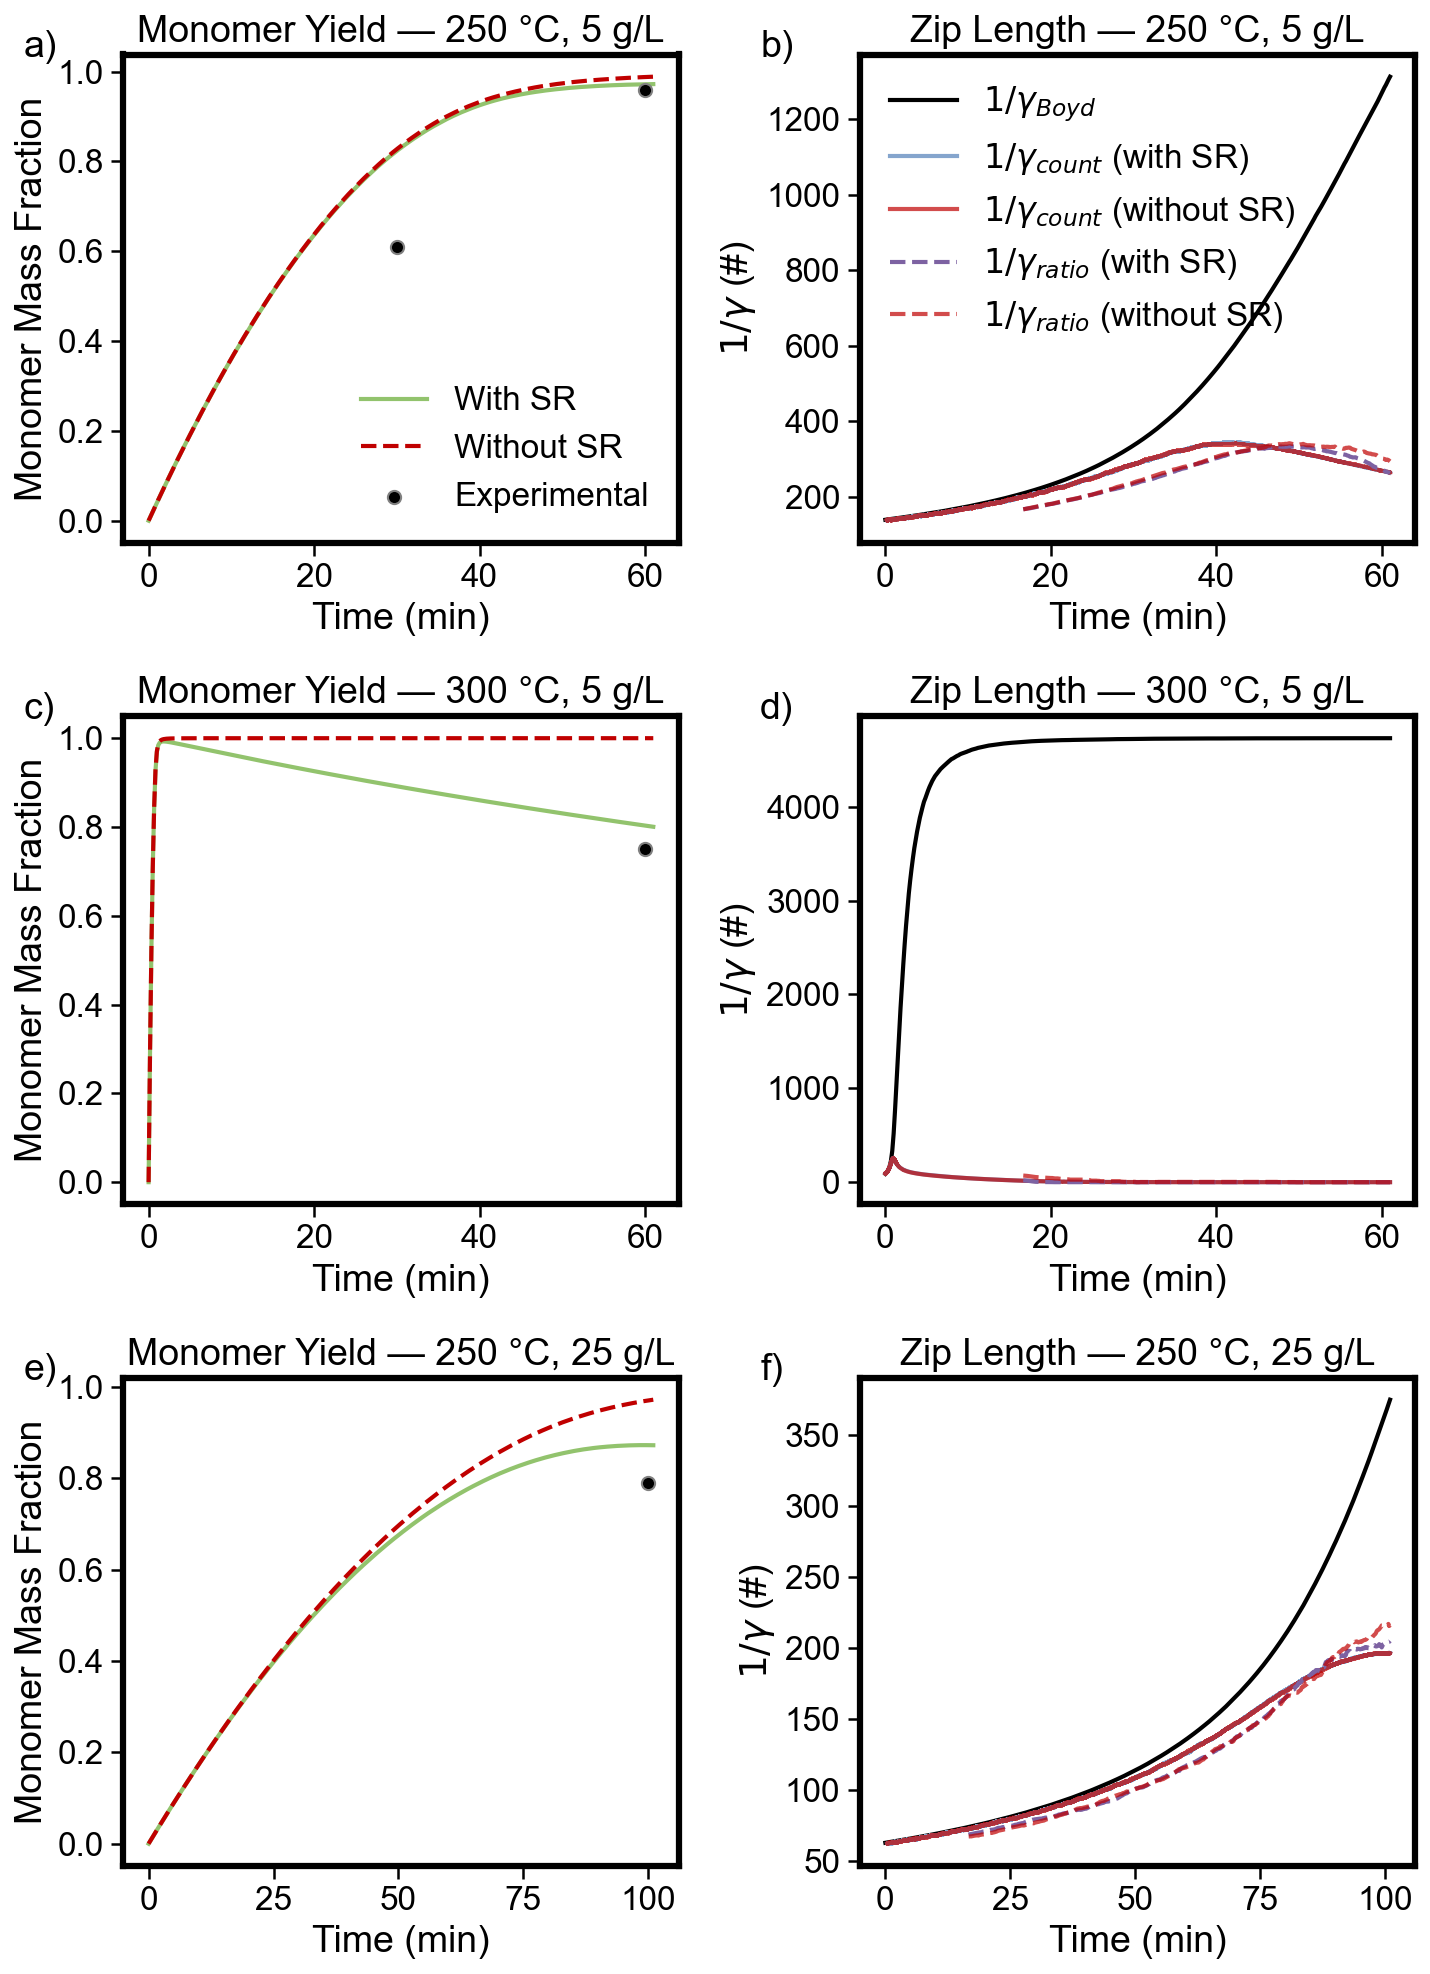

In [40]:
# Load all three conditions WITH side reaction
data_250 = read_data(f'../kmc_src/polyME_cpp_files_conv/run_conv_4_2_26/run_025_T_250')
df_250 = process_data(data_250)
data_300 = read_data(f'../kmc_src/polyME_cpp_files_conv/run_conv_4_2_26/run_025_T_300')
df_300 = process_data(data_300)
data_high_rho = read_data(f'../kmc_src/polyME_cpp_files_conv/run_conv_4_2_26/run_025_T_250_high_rho')
df_high_rho = process_data(data_high_rho)

# Load all three conditions WITHOUT side reaction
data_250_nosr = read_data(f'../kmc_src/polyME_cpp_files_conv/no_sr_run_conv_4_2_26/run_025_T_250')
df_250_nosr = process_data(data_250_nosr)
data_300_nosr = read_data(f'../kmc_src/polyME_cpp_files_conv/no_sr_run_conv_4_2_26/run_025_T_300')
df_300_nosr = process_data(data_300_nosr)
data_high_rho_nosr = read_data(f'../kmc_src/polyME_cpp_files_conv/no_sr_run_conv_4_2_26/run_025_T_250_high_rho')
df_high_rho_nosr = process_data(data_high_rho_nosr)

# Bundle into rows: (label, data_sr, df_sr, data_nosr, df_nosr, exp_points)
rows = [
(r'250 °C, 5 g/L',  data_250,      df_250,      data_250_nosr,      df_250_nosr,      [(30, .61), (60, .96)]),
(r'300 °C, 5 g/L',  data_300,      df_300,      data_300_nosr,      df_300_nosr,      [(60, .75)]),
(r'250 °C, 25 g/L', data_high_rho, df_high_rho, data_high_rho_nosr, df_high_rho_nosr, [(100, .79)]),
]

fig, axes = plt.subplots(3, 2, figsize=(2 * plotsize, 3 * plotsize * 0.9))
plt.subplots_adjust(wspace=0.3, hspace=0.45)

panel_labels = [['a)', 'b)'], ['c)', 'd)'], ['e)', 'f)']]

for row_idx, (condition_label, data_sr, df_sr, data_nosr, df_nosr, exp_pts) in enumerate(rows):

        # ── Left panel: Monomer yield ───────────────────────────────────────
        ax = axes[row_idx][0]

        # With SR
        try:
                ax.plot(df_sr['Time (min)'], df_sr['Monomer Wt Fraction'],
                        label='With SR', c=cdict['green'], linewidth=2)
        except:
                ax.plot(df_sr['Time (min)'], df_sr['Monomer Conversion'],
                        label='With SR', c=cdict['green'], linewidth=2)

        # Without SR
        try:
                ax.plot(df_nosr['Time (min)'], df_nosr['Monomer Wt Fraction'],
                        label='Without SR', c=cdict['red'], linewidth=2, linestyle='--')
        except:
                ax.plot(df_nosr['Time (min)'], df_nosr['Monomer Conversion'],
                        label='Without SR', c=cdict['red'], linewidth=2, linestyle='--')

        # Experimental points
        for t_exp, y_exp in exp_pts:
                ax.scatter([t_exp], [y_exp], s=40, edgecolor='gray', c='k',
                        zorder=5, label='Experimental' if t_exp == exp_pts[0][0] else '_nolegend_')

        ax.set_xlabel('Time (min)')
        ax.set_ylabel('Monomer Mass Fraction')
        ax.set_title(f'Monomer Yield — {condition_label}')
        ax.text(-0.18, 1.05, panel_labels[row_idx][0],
                transform=ax.transAxes, va='top', ha='left')

        # Legend only on first row
        if row_idx == 0:
                ax.legend(framealpha=0.8)

        # ── Right panel: Zip length ─────────────────────────────────────────
        ax = axes[row_idx][1]

        win_sr = int(len(data_sr['zip_length_df']['Zip Length (#)']) / 100)
        win_nosr = int(len(data_nosr['zip_length_df']['Zip Length (#)']) / 100)

        # Boyd benchmark — only from SR simulation (identical by construction)
        ax.plot(df_sr['Time (min)'],
                df_sr['Corrected ZL'].rolling(window=1).mean(),
                label=r'$1/\gamma_{Boyd}$', c='k', linewidth=2)

        # 1/gamma_count with SR
        ax.plot(data_sr['zip_length_df']['Zip End Time (s)'] / 60,
                data_sr['zip_length_df']['Zip Length (#)'].rolling(window=win_sr).mean(),
                label=r'$1/\gamma_{count}$ (with SR)', c=cdict['lightblue'], linewidth=2)

        # 1/gamma_count without SR
        ax.plot(data_nosr['zip_length_df']['Zip End Time (s)'] / 60,
                data_nosr['zip_length_df']['Zip Length (#)'].rolling(window=win_nosr).mean(),
                label=r'$1/\gamma_{count}$ (without SR)', c=cdict['red'],
                linewidth=2, linestyle='-', alpha=0.7)

        # 1/gamma_ratio with SR
        ax.plot(df_sr['Time (min)'].iloc[1:],
                df_sr['2a'].iloc[1:].rolling(window=100).mean(),
                label=r'$1/\gamma_{ratio}$ (with SR)', c=cdict['purple2'],
                linewidth=2, linestyle='--')

        # 1/gamma_ratio without SR
        ax.plot(df_nosr['Time (min)'].iloc[1:],
                df_nosr['2a'].iloc[1:].rolling(window=100).mean(),
                label=r'$1/\gamma_{ratio}$ (without SR)', c=cdict['red'],
                linewidth=2, linestyle='--', alpha=0.7)

        ax.set_xlabel('Time (min)')
        ax.set_ylabel(r'$1/\gamma$ (#)')
        ax.set_title(f'Zip Length — {condition_label}')
        ax.text(-0.18, 1.05, panel_labels[row_idx][1],
                transform=ax.transAxes, va='top', ha='left')

        # Legend only on first row
        if row_idx == 0:
                ax.legend(framealpha=0.8)

plt.tight_layout()
plt.savefig('fig_pdfs/figS5_no_SR.pdf', dpi=300, bbox_inches='tight')
plt.show()

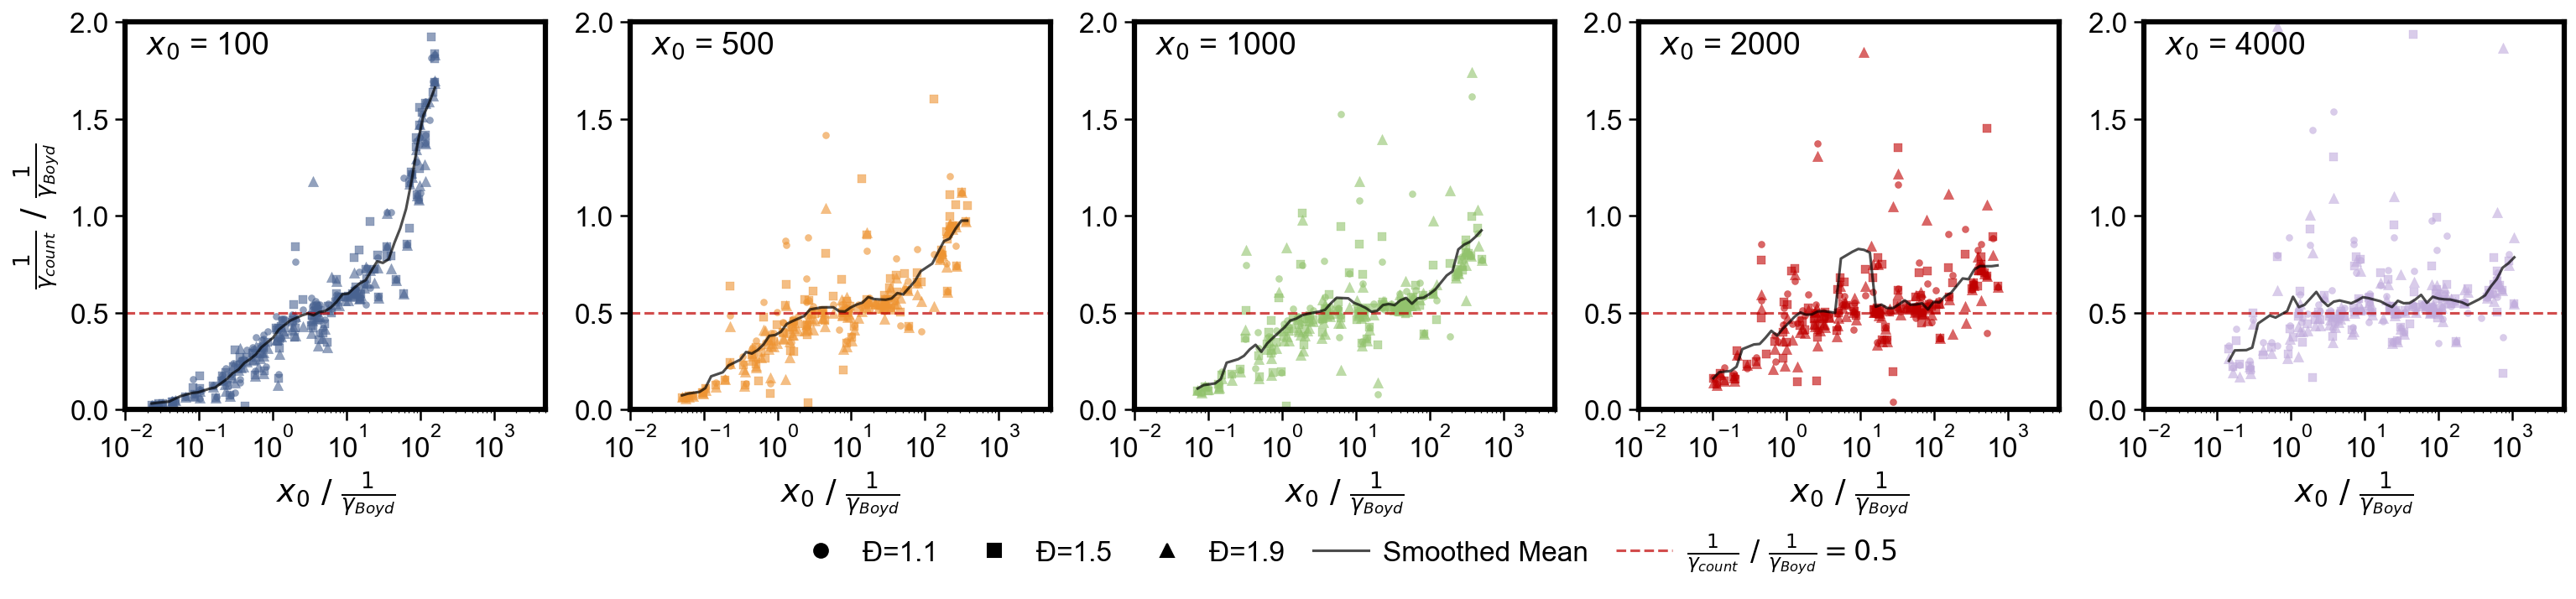

In [41]:
# Font sizes
LABEL_SIZE = 18
TICK_SIZE = 16
LEGEND_SIZE = 16
TITLE_SIZE = 18

# Marker sizes by dispersity - more distinct
marker_size_map = {1.1: plotsize*3, 1.5: plotsize*5, 1.9: plotsize*7}

fig, axes_grid = plt.subplots(1, 5, figsize=(5*plotsize, 0.8*plotsize))

legend_handles = []  # collect handles for universal legend

for idx, x0 in enumerate([100, 500, 1000, 2000, 4000]):
    ax = axes_grid[idx]

    for disp in disp_list:
        mask = (df_eci['dpn'] == x0) & (df_eci['disp'] == disp) & (df_eci['N rows'] < 5E5)
        if not mask.any():
            continue
        x = df_eci.loc[mask, 'x-axis']
        y = df_eci.loc[mask, 'ratio1']
        sc = ax.scatter(
            x, y,
            color=color_map[x0],
            marker=marker_map[disp],
            alpha=0.6,
            s=marker_size_map[disp],
            linewidths=0.2,
            label=f"Đ={disp}"
        )
        # Only collect legend handles from first panel to avoid duplicates
        if idx == 0:
            legend_handles.append(sc)

    # Add average line across all dispersities
    mask_all = (df_eci['dpn'] == x0) & (df_eci['N rows'] < 5E5) & (df_eci['ratio1'] < 2)
    if mask_all.any():
        x_all = df_eci.loc[mask_all, 'x-axis'].copy()
        y_all = df_eci.loc[mask_all, 'ratio1'].copy()

        n_bins = max(50, len(x_all) // 15)
        x_all_log = np.log10(x_all)
        bin_edges = np.linspace(x_all_log.min(), x_all_log.max(), n_bins)
        bin_indices = np.digitize(x_all_log, bin_edges)

        bin_centers = []
        bin_means = []
        for bin_idx in np.unique(bin_indices):
            mask_bin = (bin_indices == bin_idx)
            if mask_bin.sum() > 0:
                bin_centers.append(10 ** bin_edges[bin_idx - 1])
                bin_means.append(y_all[mask_bin].mean())

        if bin_centers:
            sorted_idx = np.argsort(bin_centers)
            bin_centers_sorted = np.array(bin_centers)[sorted_idx]
            bin_means_sorted = np.array(bin_means)[sorted_idx]
            smooth_means = pd.Series(bin_means_sorted).rolling(
                window=5, center=True, min_periods=1
            ).mean().values
            line, = ax.plot(
                bin_centers_sorted, smooth_means,
                color='k', alpha=0.7, linewidth=1.5,
                label='Smoothed Mean', zorder=10
            )
            # Collect smoothed mean handle only once
            if idx == 0:
                legend_handles.append(line)

    ax.set_xscale('log')
    ax.set_xlabel(r"$x_0\ /\ \frac{1}{\gamma_{Boyd}}$", fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)

    if idx == 0:
        ax.set_ylabel(
            r"$\frac{1}{\gamma_{count}}\ /\ \frac{1}{\gamma_{Boyd}}$",
            fontsize=LABEL_SIZE
        )

    ax.set_ylim([0, 2])
    ax.set_xlim([0.01, 5E3])

    # Panel title inside bottom right to avoid legend overlap
    ax.text(
        0.05, 0.9, f"$x_0$ = {x0}",
        transform=ax.transAxes,
        fontsize=TITLE_SIZE, 
        va='bottom', ha='left'
    )

    # Reference line at 0.5 with label
    line = ax.axhline(0.5, alpha=0.7, color=cdict['red'], linestyle='--', linewidth=1.5, label=r"$\frac{1}{\gamma_{count}}\ /\ \frac{1}{\gamma_{Boyd}} = 0.5$")
    if idx == 0:
        legend_handles.append(line)

    # No per-panel legends
    ax.legend().set_visible(False)

# Universal legend below middle panel
from matplotlib.lines import Line2D

# Replace scatter handles with black marker-only handles for legend
black_disp_handles = [
    Line2D([0], [0], marker=marker_map[disp], color='w', 
           markerfacecolor='k', markeredgecolor='k',
           markersize=8, label=f"Đ={disp}")
    for disp in disp_list
]

# Rebuild legend_handles: black dispersity markers + smoothed mean + reference line
final_legend_handles = black_disp_handles + [h for h in legend_handles if not isinstance(h, PathCollection)]

axes_grid[2].legend(
    handles=final_legend_handles,
    fontsize=LEGEND_SIZE,
    framealpha=0.8,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=len(final_legend_handles),
    handletextpad=0.5,
    columnspacing=1.0
)
# plt.tight_layout()
plt.savefig("fig_pdfs/figS3_all_x0s.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [42]:
data_low = read_data(f'../parameter_exploration/compare_radicals/run_169_low')
df_low = process_data_eci(data_low)

data_plateau = read_data(f'../parameter_exploration/compare_radicals/run_1_med')
df_plateau = process_data_eci(data_plateau)

data_overshoot = read_data(f'../parameter_exploration/compare_radicals/run_118_over')
df_overshoot = process_data_eci(data_overshoot)

case_dict = {
    r"low": [0, data_low, df_low, r"T = 250 $\degree$C, $\rho$ = 5 g/L"],
    r"plat": [1, data_plateau, df_plateau, r"T = 300 $\degree$C, $\rho$ = 5 g/L"],
    r"overshoot": [2, data_overshoot, df_overshoot, r"T = 250 $\degree$C   $\rho$ = 25 g/L"],
}

fig, ax = plt.subplots(3, len(case_dict), figsize=(plotsize * len(case_dict)+0.1, plotsize * 3.5))
plt.subplots_adjust(hspace=0.5)

legend_handles = [[], [], []]
legend_labels  = [[], [], []]

for name, [i, data, df, label] in case_dict.items():

    # Suppress y-axis labels on non-leftmost panels
    if i == 0:
        ax[0][i].set_ylabel("Mass Fraction")
        ax[1][i].set_ylabel(r"$C_{R•}$ (mol/L)")
        ax[2][i].set_ylabel(r"$1/\gamma$ (#)")
    else:
        for row in range(3):
            ax[row][i].set_ylabel('')
        ax[1][i].tick_params(labelleft=False)
        ax[2][i].tick_params(labelleft=False)

    # Row 0: Mass yields
    try:
        l2, = ax[0][i].plot(df['Time (min)'], df['Monomer Wt Fraction'], label='Monomer', c=cdict['green'])
    except:
        l2, = ax[0][i].plot(df['Time (min)'], df['Monomer Conversion'], label='Monomer', c=cdict['green'])
    l3, = ax[0][i].plot(df['Time (min)'], df['Polymer Wt Fraction'], label='Polymer', c=cdict['darkblue'])

    ax[0][i].set_xlabel("Time (min)")
    if i == 0:
        legend_handles[0] = [l2, l3]
        legend_labels[0]  = ['Monomer', 'Polymer']

    # Row 1: Radical concentration
    timewindow = 25
    l1, = ax[1][i].plot(df['Time (min)'], df["Radical Conc BS"].rolling(window=timewindow).mean(),
                        label=r'$C_{R•,D}$', c=cdict['lightpurple'])
    l2, = ax[1][i].plot(df['Time (min)'], df["Radical Conc RR"].rolling(window=timewindow).mean(),
                        label=r'$C_{R•,T}$', c=cdict['green'])

    ax[1][i].set_xlabel("Time (min)")
    if i == 0:
        legend_handles[1] = [l1, l2]
        legend_labels[1]  = [r'$C_{R•,D}$', r'$C_{R•,T}$', r"$C_{R•,Boyd}$"]

    # Row 2: Zip length
    win = int(len(data['zip_length_df']['Zip Length (#)']) / 100)
    l1, = ax[2][i].plot(df['Time (min)'], df['Corrected ZL'].rolling(window=1).mean(),
                        label=r'$1/\gamma_{Boyd}$', c='k')
    l2, = ax[2][i].plot(data['zip_length_df']['Zip End Time (s)'] / 60,
                        data['zip_length_df']['Zip Length (#)'].rolling(window=win).mean(),
                        label=r'$1/\gamma_{count}$', c=cdict['lightblue'])
    l3, = ax[2][i].plot(df['Time (min)'].iloc[1:], df['2a'].iloc[1:].rolling(window=30).mean(),
                        label=r'$1/\gamma_{ratio}$', linestyle='--', c=cdict['purple2'])
    ax[2][i].set_xlabel("Time (min)")
    if i == 0:
        legend_handles[2] = [l1, l2, l3]
        legend_labels[2]  = [r'$1/\gamma_{Boyd}$', r'$1/\gamma_{count}$', r'$1/\gamma_{ratio}$']

# Subplot labels
ax[0][0].text(-0.2, 1.08, 'a)', transform=ax[0][0].transAxes, va='top', ha='left')
ax[0][1].text(-0.2, 1.08, 'b)', transform=ax[0][1].transAxes, va='top', ha='left')
ax[0][2].text(-0.2, 1.08, 'c)', transform=ax[0][2].transAxes, va='top', ha='left')

# Inline labels row 0
ax[0][0].text(0.6, 0.3, "Polymer", transform=ax[0][0].transAxes, va='top', ha='left', c=cdict['darkblue'], fontweight='bold')
ax[0][0].text(0.6, 0.8, "Monomer", transform=ax[0][0].transAxes, va='top', ha='left', c=cdict['green'], fontweight='bold')

# Inline labels row 1
ax[1][0].text(0.7, 0.9, r'$C_{R•,Boyd}$', transform=ax[1][0].transAxes, va='top', ha='left', c=cdict['black'], fontweight='bold')
ax[1][0].text(0.7, 0.8, r'$C_{R•,T}$', transform=ax[1][0].transAxes, va='top', ha='left', c=cdict['green'], fontweight='bold')
ax[1][0].text(0.7, 0.7, r'$C_{R•,D}$', transform=ax[1][0].transAxes, va='top', ha='left', c=cdict['lightpurple'], fontweight='bold')

# Inline labels row 2
ax[2][0].text(0.2, 0.9, r'$1/\gamma_{Boyd}$', transform=ax[2][0].transAxes, va='top', ha='left', c=cdict['black'], fontweight='bold')
ax[2][0].text(0.2, 0.8, r'$1/\gamma_{count}$', transform=ax[2][0].transAxes, va='top', ha='left', c=cdict['lightblue'], fontweight='bold')
ax[2][0].text(0.2, 0.7, r'$1/\gamma_{ratio}$', transform=ax[2][0].transAxes, va='top', ha='left', c=cdict['purple2'], fontweight='bold')

plt.savefig(f"fig_pdfs/figS4_radicals_scheme2.pdf", dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../parameter_exploration/compare_radicals/run_169_low'